# Separate Clusters in 3D

Continuation of the [exploratory notebook](final_eda.ipynb): an expanded feature set,
clipping extreme values, logarithmic transformations, categorical features,
3D PCA, and a UMAP + HDBSCAN experiment. The default is a sample of 10,000 rows,
not the full dataset.

This is an exploratory extension, not a validated improvement over the full-data pipeline.
Results and limitations: [notebook review](../docs/separate_clusters_3D_review.md).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

sns.set_theme(style="whitegrid")


## Load data


In [2]:
df = pd.read_csv('../data/raw/instagram_usage_lifestyle.csv')

print('rows:', len(df))
print('cols:', df.shape[1])

df.head(3)


rows: 1547896
cols: 58


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67


## Column pruning


In [3]:
df_work = df.copy()

# Drop columns not needed for behavioral segmentation at this stage
drop_cols = [
    "user_id",
    "app_name",
    "age",
    "gender",
    "country",
    "urban_rural",
    "employment_status",
    "education_level",
    "relationship_status",
    "has_children",
    "diet_quality",
    "smoking",
    "alcohol_frequency",
    "last_login_date",
]

df_work.drop(columns=drop_cols, inplace=True, errors='ignore')

print('rows:', len(df_work))
print('cols:', df_work.shape[1])


rows: 1547896
cols: 44


## Sampling


In [4]:
# Use the same 10,000-row sample as the main analysis by default.
SAMPLE_N = 10000  # e.g., 50000

if SAMPLE_N and len(df_work) > SAMPLE_N:
    df_work = df_work.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

print('rows:', len(df_work))


rows: 10000


## Feature engineering


In [5]:
df_work['creator_post_ratio'] = (
    df_work['posts_created_per_week'] / (df_work['sessions_per_day'] + 1)
)

df_work['broadcast_ratio'] = (
    df_work['posts_created_per_week'] /
    (df_work['stories_viewed_per_day'] + df_work['reels_watched_per_day'] + 1)
)

df_work['audience_ratio'] = (
    df_work['followers_count'] / (df_work['following_count'] + 1)
)

df_work[['creator_post_ratio', 'broadcast_ratio', 'audience_ratio']].describe().T


,count,mean,std,min,25%,50%,75%,max
creator_post_ratio,10000.0,0.731986,0.669720,0.000000,0.315789,0.535714,1.000000,7.000000
broadcast_ratio,10000.0,0.022398,0.013477,0.000000,0.013199,0.020280,0.028986,0.126761
audience_ratio,10000.0,0.900368,0.508664,0.399083,0.519118,0.717103,1.125737,6.211179


## Feature set


In [6]:
# Base (raw) activity features
activity_cols_base = [
    'user_engagement_score',
    'sessions_per_day',
    'daily_active_minutes_instagram',
    'average_session_length_minutes',
    'likes_given_per_day',
    'comments_written_per_day',
    'stories_viewed_per_day',
    'reels_watched_per_day',
    'time_on_feed_per_day',
    'time_on_reels_per_day',
    'time_on_explore_per_day',
    'time_on_messages_per_day',
    'posts_created_per_week',
    'dms_sent_per_week',
    'dms_received_per_week',
    'ads_viewed_per_day',
    'ads_clicked_per_day',
    'notification_response_rate',
]

creator_cols = [
    'creator_post_ratio',
    'broadcast_ratio',
    'audience_ratio',
    'followers_count',
    'following_count',
]

# Log1p transforms for skewed counts (with clipping)
log_transform_cols = [
    'followers_count',
    'following_count',
    'dms_sent_per_week',
    'dms_received_per_week',
    'ads_viewed_per_day',
    'ads_clicked_per_day',
    'time_on_feed_per_day',
    'time_on_reels_per_day',
    'time_on_explore_per_day',
    'time_on_messages_per_day',
    'posts_created_per_week',
    'sessions_per_day',
]

# Reduce skew and outlier impact in activity features
# 1) Clip extreme values at 99th percentile
# 2) Log-transform clipped values
for col in activity_cols_base:
    upper = df_work[col].quantile(0.99)
    df_work[col + '_clip'] = df_work[col].clip(upper=upper)
    # log1p only for specified skewed columns
    if col in log_transform_cols:
        df_work[col + '_log'] = np.log1p(df_work[col + '_clip'])
    else:
        df_work[col + '_log'] = df_work[col + '_clip']

# Apply log1p to followers/following with clipping
for col in ['followers_count', 'following_count']:
    upper = df_work[col].quantile(0.99)
    df_work[col + '_clip'] = df_work[col].clip(upper=upper)
    df_work[col + '_log'] = np.log1p(df_work[col + '_clip'])

activity_cols = [col + '_log' for col in activity_cols_base]

# Numeric features (scaled)
num_cols = activity_cols + [
    'creator_post_ratio',
    'broadcast_ratio',
    'audience_ratio',
    'followers_count_log',
    'following_count_log',
]
XY_num = df_work[num_cols]

# Categorical features (one-hot)
cat_cols = [
    'uses_premium_features',
    'subscription_status',
    'privacy_setting_level',
    'two_factor_auth_enabled',
    'biometric_login_used',
    'content_type_preference',
    'preferred_content_theme',
]

XY_cat = pd.get_dummies(df_work[cat_cols], drop_first=True)

# Optional: drop highly correlated numeric features (keep threshold conservative)
CORR_THRESHOLD = 0.90
corr = XY_num.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_corr = [column for column in upper.columns if any(upper[column] > CORR_THRESHOLD)]
if drop_corr:
    XY_num = XY_num.drop(columns=drop_corr)
    print('dropped correlated numeric features:', drop_corr)

# Combined feature matrix for clustering
XY = pd.concat([XY_num, XY_cat], axis=1)
feature_names = XY.columns.tolist()

XY.shape


dropped correlated numeric features: ['likes_given_per_day_log', 'comments_written_per_day_log', 'stories_viewed_per_day_log', 'time_on_reels_per_day_log', 'time_on_explore_per_day_log', 'time_on_messages_per_day_log', 'following_count_log']


(10000, 35)

## Scaling and PCA diagnostics


In [7]:
scaler = StandardScaler()
XY_num_scaled = scaler.fit_transform(XY_num)

# Keep one-hot categorical features unscaled
XY_scaled = np.hstack([XY_num_scaled, XY_cat.values])

pca_full = PCA().fit(XY_scaled)

var_df = pd.DataFrame({
    'component': np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    'explained_var': pca_full.explained_variance_ratio_,
})
var_df['cumulative_var'] = var_df['explained_var'].cumsum()

var_df.head(10)


,component,explained_var,cumulative_var
0,1,0.404056,0.404056
1,2,0.126161,0.530217
2,3,0.067079,0.597296
3,4,0.058117,0.655413
4,5,0.053016,0.708429
5,6,0.045260,0.753689
6,7,0.027016,0.780705
7,8,0.022376,0.803081
8,9,0.017633,0.820714
9,10,0.014629,0.835343


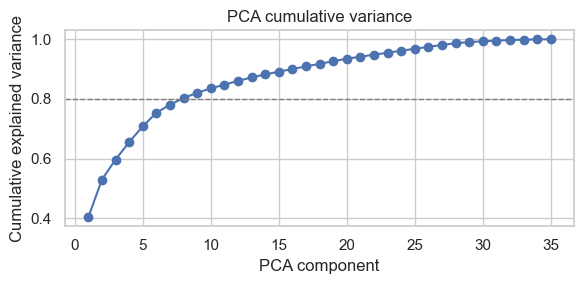

In [118]:
plt.figure(figsize=(6, 3))
plt.plot(var_df['component'], var_df['cumulative_var'], marker='o')
plt.axhline(0.8, color='gray', linestyle='--', linewidth=1)
plt.xlabel('PCA component')
plt.ylabel('Cumulative explained variance')
plt.title('PCA cumulative variance')
plt.tight_layout()
plt.show()


In [8]:
pca = PCA(n_components=3, random_state=42)
XY_pca = pca.fit_transform(XY_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['PCA1', 'PCA2', 'PCA3']
)

loadings.sort_values('PCA1', ascending=False)


,PCA1,PCA2,PCA3
time_on_feed_per_day_log,0.349754,-0.032668,0.108923
daily_active_minutes_instagram_log,0.341214,0.079252,-0.074058
dms_received_per_week_log,0.337154,0.031219,0.005472
ads_viewed_per_day_log,0.330245,0.022118,0.006778
dms_sent_per_week_log,0.328234,0.042410,-0.023263
sessions_per_day_log,0.322059,-0.017518,-0.357510
reels_watched_per_day_log,0.312258,0.169464,-0.048320
ads_clicked_per_day_log,0.276961,0.019554,-0.009605
posts_created_per_week_log,0.169774,0.537276,-0.035991
average_session_length_minutes_log,0.096205,0.007058,0.844848


## Cluster selection


In [121]:
k_values = range(2, 11)
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(XY_pca)

    rows.append({
        'k': k,
        'silhouette': silhouette_score(XY_pca, labels),
        'calinski_harabasz': calinski_harabasz_score(XY_pca, labels),
        'davies_bouldin': davies_bouldin_score(XY_pca, labels),
    })

metrics_df = pd.DataFrame(rows).set_index('k')
metrics_df


,silhouette,calinski_harabasz,davies_bouldin
k,,,
2,0.430878,8099.802002,0.985974
3,0.377307,8516.319598,0.959583
4,0.324150,7332.226761,1.107152
5,0.287835,6798.740549,1.169720
6,0.281967,6387.528647,1.141911
7,0.273132,6105.296141,1.118341
8,0.255337,5833.458109,1.089219
9,0.253555,5628.085780,1.166461
10,0.259635,5521.722552,1.031512


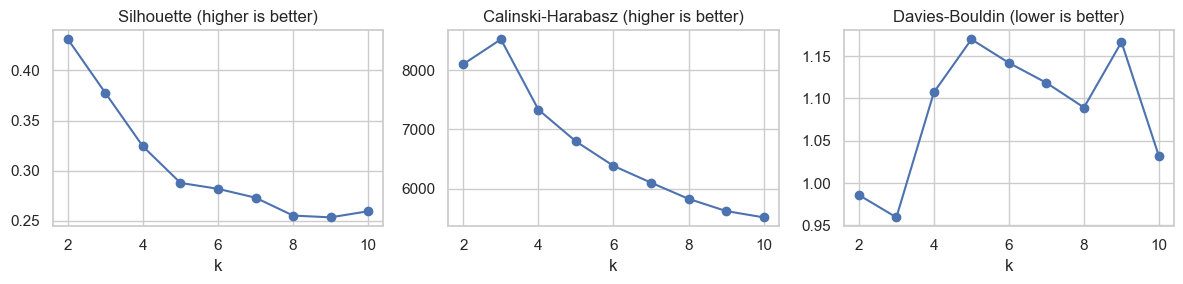

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

metrics_df['silhouette'].plot(ax=axes[0], marker='o')
axes[0].set_title('Silhouette (higher is better)')
axes[0].set_xlabel('k')

metrics_df['calinski_harabasz'].plot(ax=axes[1], marker='o')
axes[1].set_title('Calinski-Harabasz (higher is better)')
axes[1].set_xlabel('k')

metrics_df['davies_bouldin'].plot(ax=axes[2], marker='o')
axes[2].set_title('Davies-Bouldin (lower is better)')
axes[2].set_xlabel('k')

plt.tight_layout()
plt.show()


## Clustering (3D PCA)


In [123]:
k = 4
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
labels = kmeans.fit_predict(XY_pca)

plot_df = pd.DataFrame({
    'PCA1': XY_pca[:, 0],
    'PCA2': XY_pca[:, 1],
    'PCA3': XY_pca[:, 2],
    'cluster': labels.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x='PCA1', y='PCA2', z='PCA3',
    color='cluster',
    opacity=0.65,
    title=f'KMeans clusters (k={k}) on PCA space (3D)'
)

# Add cluster centers
centers = kmeans.cluster_centers_
centers_df = pd.DataFrame({
    'PCA1': centers[:, 0],
    'PCA2': centers[:, 1],
    'PCA3': centers[:, 2],
    'cluster': ['center'] * len(centers)
})

fig.add_scatter3d(
    x=centers_df['PCA1'],
    y=centers_df['PCA2'],
    z=centers_df['PCA3'],
    mode='markers',
    marker=dict(size=2, color='black', symbol='x'),
    name='centers'
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(width=600, height=600)

fig.show()


## Cluster profiles


In [124]:
df_seg = df_work.copy()
df_seg['cluster'] = labels

profile_cols = [
    'posts_created_per_week',
    'creator_post_ratio',
    'broadcast_ratio',
    'sessions_per_day',
    'daily_active_minutes_instagram',
]

df_seg.groupby('cluster')[profile_cols].mean()


,posts_created_per_week,creator_post_ratio,broadcast_ratio,sessions_per_day,daily_active_minutes_instagram
cluster,,,,,
0,4.586303,1.091802,0.026399,3.419265,71.956570
1,8.862184,0.640417,0.023815,15.808700,285.500000
2,3.890983,1.877972,0.041547,1.069987,8.458950
3,3.134687,0.364780,0.012989,8.637902,154.841624


In [125]:
income_share = (
    df_seg
     .groupby('cluster')['income_level']
     .value_counts(normalize=True)
        .unstack()
)

income_order = ['Low', 'Lower-middle', 'Middle', 'Upper-middle', 'High']
income_share = income_share.reindex(columns=income_order)
income_share


income_level,Low,Lower-middle,Middle,Upper-middle,High
cluster,,,,,
0,0.195991,0.233853,0.308463,0.155902,0.105791
1,0.203950,0.246782,0.300488,0.146471,0.102308
2,0.197847,0.253028,0.298789,0.150740,0.099596
3,0.196954,0.255499,0.304907,0.144839,0.097800


In [126]:
print("hello world")


hello world


In [ ]:
# 3D KMeans using only float64 features (sampled)
SAMPLE_N_FLOAT = 10000 

df_float_src = df
if SAMPLE_N_FLOAT and len(df_float_src) > SAMPLE_N_FLOAT:
    df_float_src = df_float_src.sample(n=SAMPLE_N_FLOAT, random_state=42).reset_index(drop=True)

float_cols = df_float_src.select_dtypes(include=['float64']).columns.tolist()
float_cols = [c for c in float_cols if c not in ['user_id']]

XY_float = df_float_src[float_cols].copy()

# Simple preprocessing: fill NAs (if any), clip & log1p skewed positives
XY_float = XY_float.fillna(0)
for col in XY_float.columns:
    upper = XY_float[col].quantile(0.99)
    XY_float[col] = XY_float[col].clip(upper=upper)
    if (XY_float[col] >= 0).all():
        XY_float[col] = np.log1p(XY_float[col])

scaler = StandardScaler()
XY_float_scaled = scaler.fit_transform(XY_float)

pca_float = PCA(n_components=3, random_state=42)
XY_float_pca = pca_float.fit_transform(XY_float_scaled)

k = 4
kmeans_float = KMeans(n_clusters=k, n_init=20, random_state=42)
labels_float = kmeans_float.fit_predict(XY_float_pca)

plot_df = pd.DataFrame({
    'PCA1': XY_float_pca[:, 0],
    'PCA2': XY_float_pca[:, 1],
    'PCA3': XY_float_pca[:, 2],
    'cluster': labels_float.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x='PCA1', y='PCA2', z='PCA3',
    color='cluster',
    opacity=0.65,
    title=f'KMeans clusters (k={k}) using float64 features (3D PCA, sampled)'
)

centers = kmeans_float.cluster_centers_
fig.add_scatter3d(
    x=centers[:, 0],
    y=centers[:, 1],
    z=centers[:, 2],
    mode='markers',
    marker=dict(size=6, color='black', symbol='x'),
    name='centers'
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(width=600, height=600)

fig.show()


In [128]:
# 3D KMeans using float64 + int64 features (sampled)
SAMPLE_N_NUM = 10000

df_num_src = df
if SAMPLE_N_NUM and len(df_num_src) > SAMPLE_N_NUM:
    df_num_src = df_num_src.sample(n=SAMPLE_N_NUM, random_state=42).reset_index(drop=True)

num_cols = df_num_src.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['user_id']]

XY_num = df_num_src[num_cols].copy()

# Simple preprocessing: fill NAs (if any), clip & log1p skewed positives
XY_num = XY_num.fillna(0)
for col in XY_num.columns:
    upper = XY_num[col].quantile(0.99)
    XY_num[col] = XY_num[col].clip(upper=upper)
    if (XY_num[col] >= 0).all():
        XY_num[col] = np.log1p(XY_num[col])

scaler = StandardScaler()
XY_num_scaled = scaler.fit_transform(XY_num)

pca_num = PCA(n_components=3, random_state=42)
XY_num_pca = pca_num.fit_transform(XY_num_scaled)

k = 4
kmeans_num = KMeans(n_clusters=k, n_init=20, random_state=42)
labels_num = kmeans_num.fit_predict(XY_num_pca)

plot_df = pd.DataFrame({
    'PCA1': XY_num_pca[:, 0],
    'PCA2': XY_num_pca[:, 1],
    'PCA3': XY_num_pca[:, 2],
    'cluster': labels_num.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x='PCA1', y='PCA2', z='PCA3',
    color='cluster',
    opacity=0.65,
    title=f'KMeans clusters (k={k}) using float64+int64 (3D PCA, sampled)'
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(width=600, height=600)

centers = kmeans_num.cluster_centers_
fig.add_scatter3d(
    x=centers[:, 0],
    y=centers[:, 1],
    z=centers[:, 2],
    mode='markers',
    marker=dict(size=4, color='black', symbol='x'),
    name='centers'
)

fig.show()


In [187]:
# Final: use sampled data + numeric + encoded categorical features
SAMPLE_N_ALL = 10000

df_all = df.copy()
if SAMPLE_N_ALL and len(df_all) > SAMPLE_N_ALL:
    df_all = df_all.sample(n=SAMPLE_N_ALL, random_state=42).reset_index(drop=True)

# Drop ID-like or constant columns
drop_cols = ['user_id', 'app_name']
df_all = df_all.drop(columns=drop_cols, errors='ignore')

# Binary encodings
binary_cols = [
    'has_children',
    'uses_premium_features',
    'two_factor_auth_enabled',
    'biometric_login_used',
]
for col in binary_cols:
    if col in df_all.columns:
        df_all[col] = df_all[col].map({'Yes': 1, 'No': 0, 'True': 1, 'False': 0, True: 1, False: 0})
        df_all[col] = df_all[col].fillna(0)

# Ordinal encodings
income_map = {'Low': 0, 'Lower-middle': 1, 'Middle': 2, 'Upper-middle': 3, 'High': 4}
education_map = {
    'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4
}
privacy_map = {'Low': 0, 'Medium': 1, 'High': 2}
urban_map = {'Rural': 0, 'Suburban': 1, 'Urban': 2}

if 'income_level' in df_all.columns:
    df_all['income_level_ord'] = df_all['income_level'].map(income_map)
if 'education_level' in df_all.columns:
    df_all['education_level_ord'] = df_all['education_level'].map(education_map)
if 'privacy_setting_level' in df_all.columns:
    df_all['privacy_setting_level_ord'] = df_all['privacy_setting_level'].map(privacy_map)
if 'urban_rural' in df_all.columns:
    df_all['urban_rural_ord'] = df_all['urban_rural'].map(urban_map)

# Date feature: days since last login
if 'last_login_date' in df_all.columns:
    last_login = pd.to_datetime(df_all['last_login_date'], errors='coerce')
    max_date = last_login.max()
    if pd.isna(max_date):
        df_all['days_since_last_login'] = 0
    else:
        df_all['days_since_last_login'] = (max_date - last_login).dt.days

# Numeric features
num_cols = df_all.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Add ordinal features to numeric list if created
for c in ['income_level_ord', 'education_level_ord', 'privacy_setting_level_ord', 'urban_rural_ord', 'days_since_last_login']:
    if c in df_all.columns and c not in num_cols:
        num_cols.append(c)

X_num = df_all[num_cols].copy()
X_num = X_num.replace([np.inf, -np.inf], np.nan)

# Drop all-NaN columns before impute
all_nan_cols = X_num.columns[X_num.isna().all()].tolist()
if all_nan_cols:
    X_num = X_num.drop(columns=all_nan_cols)
    print('dropped all-NaN numeric cols:', all_nan_cols)

X_num = X_num.fillna(X_num.median(numeric_only=True))

# Nominal categories -> one-hot (limit high-cardinality by top-K)
nominal_cols = [
    'gender',
    'country',
    'employment_status',
    'relationship_status',
    'diet_quality',
    'smoking',
    'alcohol_frequency',
    'content_type_preference',
    'preferred_content_theme',
    'subscription_status',
]
nominal_cols = [c for c in nominal_cols if c in df_all.columns]

TOP_K = 30
df_nom = df_all[nominal_cols].copy()
for c in nominal_cols:
    df_nom[c] = df_nom[c].astype('object').fillna('Unknown')
    top = df_nom[c].value_counts().nlargest(TOP_K).index
    df_nom[c] = df_nom[c].where(df_nom[c].isin(top), other='Other')

X_cat = pd.get_dummies(df_nom, drop_first=True)

# Combine
X = pd.concat([X_num, X_cat], axis=1)

# Scale numeric only, keep one-hot as is
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_scaled = np.hstack([X_num_scaled, X_cat.values])

# Final safeguard: replace any remaining NaN/inf
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# PCA -> 3D
pca_all = PCA(n_components=3, random_state=42)
X_pca = pca_all.fit_transform(X_scaled)

k = 4
kmeans_all = KMeans(n_clusters=k, n_init=20, random_state=42)
labels_all = kmeans_all.fit_predict(X_pca)

plot_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'PCA3': X_pca[:, 2],
    'cluster': labels_all.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x='PCA1', y='PCA2', z='PCA3',
    color='cluster',
    opacity=0.6,
    title=f'KMeans clusters (k={k}) on sampled data with encoded categoricals (3D PCA)'
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(width=600, height=600)

centers = kmeans_all.cluster_centers_
fig.add_scatter3d(
    x=centers[:, 0],
    y=centers[:, 1],
    z=centers[:, 2],
    mode='markers',
    marker=dict(size=4, color='black', symbol='x'),
    name='centers'
)

fig.show()


dropped all-NaN numeric cols: ['education_level_ord', 'privacy_setting_level_ord']


In [9]:
# UMAP (3D) + HDBSCAN on sampled data with encoded categoricals
import umap
import hdbscan

SAMPLE_N_UMAP = 10000

df_umap = df.copy()
if SAMPLE_N_UMAP and len(df_umap) > SAMPLE_N_UMAP:
    df_umap = df_umap.sample(n=SAMPLE_N_UMAP, random_state=42).reset_index(drop=True)

# Drop ID-like or constant columns
df_umap = df_umap.drop(columns=['user_id', 'app_name'], errors='ignore')

# Binary encodings
binary_cols = [
    'has_children',
    'uses_premium_features',
    'two_factor_auth_enabled',
    'biometric_login_used',
]
for col in binary_cols:
    if col in df_umap.columns:
        df_umap[col] = df_umap[col].map({'Yes': 1, 'No': 0, 'True': 1, 'False': 0, True: 1, False: 0})
        df_umap[col] = df_umap[col].fillna(0)

# Ordinal encodings
income_map = {'Low': 0, 'Lower-middle': 1, 'Middle': 2, 'Upper-middle': 3, 'High': 4}
education_map = {
    'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4
}
privacy_map = {'Low': 0, 'Medium': 1, 'High': 2}
urban_map = {'Rural': 0, 'Suburban': 1, 'Urban': 2}

if 'income_level' in df_umap.columns:
    df_umap['income_level_ord'] = df_umap['income_level'].map(income_map)
if 'education_level' in df_umap.columns:
    df_umap['education_level_ord'] = df_umap['education_level'].map(education_map)
if 'privacy_setting_level' in df_umap.columns:
    df_umap['privacy_setting_level_ord'] = df_umap['privacy_setting_level'].map(privacy_map)
if 'urban_rural' in df_umap.columns:
    df_umap['urban_rural_ord'] = df_umap['urban_rural'].map(urban_map)

# Date feature: days since last login
if 'last_login_date' in df_umap.columns:
    last_login = pd.to_datetime(df_umap['last_login_date'], errors='coerce')
    max_date = last_login.max()
    if pd.isna(max_date):
        df_umap['days_since_last_login'] = 0
    else:
        df_umap['days_since_last_login'] = (max_date - last_login).dt.days

# Numeric features
num_cols = df_umap.select_dtypes(include=['float64', 'int64']).columns.tolist()
for c in ['income_level_ord', 'education_level_ord', 'privacy_setting_level_ord', 'urban_rural_ord', 'days_since_last_login']:
    if c in df_umap.columns and c not in num_cols:
        num_cols.append(c)

X_num = df_umap[num_cols].copy()
X_num = X_num.replace([np.inf, -np.inf], np.nan)
all_nan_cols = X_num.columns[X_num.isna().all()].tolist()
if all_nan_cols:
    X_num = X_num.drop(columns=all_nan_cols)

X_num = X_num.fillna(X_num.median(numeric_only=True))

# Nominal categories -> one-hot (limit high-cardinality by top-K)
nominal_cols = [
    'gender',
    'country',
    'employment_status',
    'relationship_status',
    'diet_quality',
    'smoking',
    'alcohol_frequency',
    'content_type_preference',
    'preferred_content_theme',
    'subscription_status',
]
nominal_cols = [c for c in nominal_cols if c in df_umap.columns]

TOP_K = 30
df_nom = df_umap[nominal_cols].copy()
for c in nominal_cols:
    df_nom[c] = df_nom[c].astype('object').fillna('Unknown')
    top = df_nom[c].value_counts().nlargest(TOP_K).index
    df_nom[c] = df_nom[c].where(df_nom[c].isin(top), other='Other')

X_cat = pd.get_dummies(df_nom, drop_first=True)

# Combine
X = pd.concat([X_num, X_cat], axis=1)

# Scale numeric only, keep one-hot as is
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_scaled = np.hstack([X_num_scaled, X_cat.values])
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# UMAP to 3D
umap_model = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
labels_umap = clusterer.fit_predict(X_umap)

plot_df = pd.DataFrame({
    'U1': X_umap[:, 0],
    'U2': X_umap[:, 1],
    'U3': X_umap[:, 2],
    'cluster': labels_umap.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x='U1', y='U2', z='U3',
    color='cluster',
    opacity=0.7,
    title='UMAP (3D) + HDBSCAN clusters (sampled, encoded)'
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(width=700, height=700)
fig.show()


c:\Users\voice\.conda\envs\project_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\voice\.conda\envs\project_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
